# otwin 04 · A band whose 90 % means 90 %

**Question.** Notebook 03 forecast a battery's health 68 cycles ahead. Now put an interval
around that forecast. How wide? And how do you know the width is right?

**What otwin does here.** Builds the interval — `split_conformal`, `horizon_conformal`,
`AdaptiveConformal` — from residuals that `rolling_origin_residuals` generates for you; then
measures it — `picp`, `mpiw`, `interval_score`, `coverage_curve`. And when the calibration set
is too small for the level you asked for, returns an infinite width rather than a
comfortable-looking one.

**What you write yourself.** The model, as in 03 — fade law plus a residual Gaussian process.
Rebuilt in one cell so this notebook stands alone.

**What you will learn**

1. why an interval built from a model's own training residuals is catastrophically wrong (1.5 % coverage at a 90 % target)
2. what a *genuine* h-step-ahead residual is, and how to get one without leaking
3. three constructions — pooled, horizon-aware, adaptive — and one number that ranks them
4. why the library refuses to fit a quantile through eight points, and what that costs

*Data: NASA PCoE cell B0005. Runtime ≈ 2 min. Opens in Colab.*


## Setup

Install, style, and the data file (upload `discharge.csv` in Colab when asked).

In [1]:
# otwin from PyPI. This is the whole point of the notebook: no clone, no path
# surgery, no vendored copy of the model code.
!pip install -q otwin 2>/dev/null
import otwin, sys
print("otwin", otwin.__version__, "| python", sys.version.split()[0])


otwin 0.3.1 | python 3.13.15


In [2]:
# Inlined plotting style. Self-contained on purpose: nothing here imports
# from another file in this repository.
import os, json
import numpy as np, pandas as pd
from scipy.optimize import curve_fit
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from otwin.forecast import (rolling_origin_residuals, split_conformal,
                            horizon_conformal, AdaptiveConformal,
                            conformal_quantile, picp, mpiw, interval_score,
                            pit_values, recalibrate, sharpness,
                            coverage_curve, expected_calibration_error, crps)

import matplotlib; import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

TEAL, RED, SLATE, GRID, OBS = "#0E7C86", "#C1121F", "#4A5568", "#E5E9EC", "black"
BAND_ALPHA = 0.18
plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
    "font.family":"DejaVu Sans","axes.titlesize":13,"axes.labelsize":11,
    "xtick.labelsize":10,"ytick.labelsize":10,"legend.fontsize":10,
    "axes.grid":True,"grid.color":GRID,"grid.linewidth":0.8,"axes.axisbelow":True,
    "figure.dpi":110,"savefig.dpi":200,
})
FIGDIR="fig"; os.makedirs(FIGDIR, exist_ok=True)
def despine(ax):
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#333333"); ax.spines["bottom"].set_color("#333333")
def save(fig, name):
    p=os.path.join(FIGDIR, name if name.endswith(".png") else name+".png")
    fig.savefig(p, dpi=200, bbox_inches="tight"); plt.show(); print("saved", p); return p


In [3]:
# The NASA PCoE discharge CSV is the only external input. Resolution order,
# with the chosen route printed:
#   (a) a download URL, if you set CANDIDATE_URL
#   (b) google.colab.files.upload()  - the normal Colab route
#   (c) a local file, for offline / CI runs

CANDIDATE_URL = ""
LOCAL_CANDIDATES = ["discharge.csv", "data/discharge.csv", "/content/discharge.csv"]
EXPECTED_ROWS = 169766
EXPECTED_CELLS = ["B0005", "B0006", "B0007", "B0018"]

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

DATA, route = None, None
if CANDIDATE_URL:
    try:
        import urllib.request
        urllib.request.urlretrieve(CANDIDATE_URL, "discharge.csv")
        DATA, route = "discharge.csv", "(a) downloaded from CANDIDATE_URL"
    except Exception as e:
        print("URL download failed:", e)
if DATA is None:
    for p in LOCAL_CANDIDATES:
        if os.path.exists(p):
            DATA, route = p, f"(c) local file: {p}"; break
if DATA is None and _in_colab():
    from google.colab import files
    up = files.upload(); DATA = list(up.keys())[0]; route = f"(b) uploaded in Colab: {DATA}"
if DATA is None:
    raise FileNotFoundError("No data source. Set CANDIDATE_URL, upload the CSV in Colab, "
                            "or put discharge.csv next to this notebook.")
print("DATA route:", route); print("DATA path :", DATA)

raw = pd.read_csv(DATA)
assert sorted(raw.Battery.unique().tolist()) == EXPECTED_CELLS, "unexpected battery IDs"
assert len(raw) == EXPECTED_ROWS, f"expected {EXPECTED_ROWS} rows, found {len(raw)}"
print("rows:", len(raw), "| cells:", sorted(raw.Battery.unique().tolist()))
print("Sanity checks passed.")


DATA route: (c) local file: discharge.csv
DATA path : discharge.csv
rows: 169766 | cells: ['B0005', 'B0006', 'B0007', 'B0018']
Sanity checks passed.


## 1 · The model, and the number that is the whole story

Same model as notebook 03, trained on cycles 1–100. The last line of the output compares two
scatters: the model's residuals *on its training data*, and its actual errors *on the 68
cycles it never saw*.

*Look at:* the ratio is **9×**. A Gaussian process interpolates its own training data almost
perfectly, so its in-sample residuals say nothing about a 68-step forecast. Every mistake in
this notebook is that ratio wearing a different hat.

In [4]:
AMBIENT = 24.0
def cycle_table(raw, battery="B0005"):
    d = raw[raw.Battery == battery].sort_values(["id_cycle", "Time"]); rows = []
    for c, g in d.groupby("id_cycle"):
        t = g.Time.to_numpy(float); v = g.Voltage_measured.to_numpy(float)
        i = np.abs(g.Current_measured.to_numpy(float))
        rows.append(dict(cycle=int(c), capacity_Ah=float(g.Capacity.iloc[0]),
                         throughput_Ah=float(np.trapezoid(i, t)/3600.0)))
    f = pd.DataFrame(rows).sort_values("cycle").reset_index(drop=True)
    f["SoH"] = f.capacity_Ah/f.capacity_Ah.iloc[0]
    f["cum_throughput_Ah"] = f.throughput_Ah.cumsum()
    return f

f = cycle_table(raw)
cyc = f.cycle.to_numpy(float); soh = f.SoH.to_numpy(float)
thr = f.throughput_Ah.to_numpy(float); cum = f.cum_throughput_Ah.to_numpy(float)
cap1 = float(f.capacity_Ah.iloc[0])
SPLIT = 100

def fit_hybrid(o, restarts=5):
    """Fit the whole pipeline using ONLY cycles 1..o. Returns a forecaster and the in-sample residuals."""
    m = cyc <= o
    k_thr = float(np.mean(thr[m]/(soh[m]*cap1)))
    po, _ = curve_fit(lambda Q, c, z: 1 - c*Q**z, cum[m], soh[m], p0=[1e-3, 1.0], maxfev=100000)
    phys_in = 1 - po[0]*cum[m]**po[1]
    X = cyc[m].reshape(-1, 1); mu, sd = X.mean(), X.std()
    r = soh[m] - phys_in
    k = ConstantKernel(np.var(r)+1e-8, (1e-8, 1e2))*Matern(1.0, (1e-2, 1e3), nu=2.5) + WhiteKernel(1e-5, (1e-10, 1e-1))
    gp = GaussianProcessRegressor(kernel=k, alpha=0.0, normalize_y=False,
                                  n_restarts_optimizer=restarts, random_state=0).fit((X-mu)/sd, r)
    Q0, s0 = cum[m][-1], soh[m][-1]
    def fc(n, ensemble=0, seed=0):
        out, Q, s = [], Q0, s0
        for _ in range(n):
            Q += k_thr*s*cap1; s = 1 - po[0]*Q**po[1]; out.append(s)
        cc = (np.arange(o+1, o+1+n).astype(float).reshape(-1, 1) - mu)/sd
        ph = np.array(out)
        if ensemble:
            return ph[:, None] + gp.sample_y(cc, n_samples=ensemble, random_state=seed)
        return ph + gp.predict(cc)
    return fc, soh[m] - (phys_in + gp.predict((X-mu)/sd))

fc100, insample = fit_hybrid(SPLIT)
n_te = int((cyc > SPLIT).sum())
pred = fc100(n_te); obs = soh[cyc > SPLIT]; H = np.arange(1, n_te+1)
print("test window: cycles %d-%d (%d steps)" % (cyc[cyc > SPLIT][0], cyc[-1], n_te))
print("in-sample residual scale: %.5f   |   actual test-window error scale: %.5f"
      % (np.std(insample), np.std(obs-pred)))
print("ratio: %.0fx. That ratio IS the negative result." % (np.std(obs-pred)/np.std(insample)))

test window: cycles 101-168 (68 steps)
in-sample residual scale: 0.00373   |   actual test-window error scale: 0.03495
ratio: 9x. That ratio IS the negative result.


## 2 · Genuine forecast errors, without leaking

To calibrate an interval you need errors that look like the errors you will make: refit the
model at an earlier origin, forecast forward *inside the training window*, and record the
error at each horizon. Nothing after cycle 100 is touched.

`rolling_origin_residuals` does the loop. You give it the refit function in the same
history-in, horizon-out shape that `evaluate` uses in notebook 03, and the origins.

*Look at:* 390 residuals over 60 horizons, from 12 origins. That is the calibration set.

In [5]:
def refit(history, horizon):
    # the leakage-free signature: history in, horizon out; the model is refit on the history only
    g, _ = fit_hybrid(float(len(history)))
    return g(horizon)

res, hor = rolling_origin_residuals(refit, soh[:SPLIT], origins=range(40, 100, 5))
print("calibration residuals generated by the library: %d over %d horizons (max h = %d)"
      % (len(res), len(np.unique(hor)), hor.max()))


calibration residuals generated by the library: 390 over 60 horizons (max h = 60)


## 3 · Four bands, one table

- **A · naive** — `split_conformal` on the in-sample residuals. The trap, on purpose.
- **B · pooled** — `split_conformal` on the rolling-origin residuals, all horizons together.
- **C · horizon-aware** — `horizon_conformal`: a quantile per horizon, wider as `h` grows.
- **D · adaptive** — `AdaptiveConformal`: the quantile is corrected online as test
  observations arrive.

Each is measured with `picp` (fraction of truths inside), `mpiw` (mean width) and
`interval_score` — a proper scoring rule that charges for width *and* for misses, so it ranks
bands without an argument about the trade-off.

*Look at:* band A covers **1.5 %** of the truth at a 90 % target. Band B, built from real
forecast errors, covers 87 %. Band C, which grows with horizon, scores best. The interval score
puts A last by a factor of five.

In [6]:
A = split_conformal(insample, level=0.90)          # the documented trap, on purpose
B = split_conformal(res, level=0.90)
C = horizon_conformal(res, hor, level=0.90, max_horizon=n_te)
aci = AdaptiveConformal(res, level=0.90, gamma=0.01)
hits = []
for k in range(n_te):
    aci.interval(pred[k]); hits.append(aci.update(obs[k]))

print(f"{'band':<26}{'PICP':>8}{'MPIW':>9}{'int.score':>11}   target PICP 0.90")
print("-"*68)
cov = {}
for name, band in (("A naive in-sample", A), ("B pooled rolling-origin", B),
                   ("C horizon-aware", C)):
    lo, hi = band.apply(pred); cov[name] = float(picp(obs, lo, hi))
    print(f"{name:<26}{cov[name]:>8.4f}{mpiw(lo,hi):>9.4f}"
          f"{interval_score(obs,lo,hi,0.90):>11.4f}")
cov["D adaptive (ACI)"] = float(np.mean(hits))
print(f"{'D adaptive (ACI)':<26}{cov['D adaptive (ACI)']:>8.4f}"
      f"{np.mean([h['width'] for h in aci.history]):>9.4f}")

band                          PICP     MPIW  int.score   target PICP 0.90
--------------------------------------------------------------------
A naive in-sample           0.0147   0.0065     1.1031
B pooled rolling-origin     0.8676   0.2089     0.2368
C horizon-aware             0.9559   0.1576     0.1660
D adaptive (ACI)            0.8235   0.2001


## 4 · Why band C refuses part of the horizon

A 90 % conformal quantile needs at least nine residuals — with fewer, the rank it asks for
does not exist. The rolling-origin set has 12 residuals at horizon 1 and 2 at horizon 55. The
first version of this experiment fitted a growth law through all sixty horizons anyway, using
the sample maximum wherever the quantile did not exist, and reported 98.5 % coverage.

`horizon_conformal` keeps only the horizons that clear the minimum, marks the rest as
**extrapolated**, and `conformal_quantile` on a too-small set returns `inf` with a warning.

*Look at:* calibrated to horizon 20, extrapolated for 48 of 68 steps, delivered 95.6 %. An
infinite half-width is useless; a half-width narrower than its own guarantee is worse than
useless. The library picks the first.

In [7]:
import collections
cnt = collections.Counter(hor.tolist())
from otwin.forecast.conformal import _min_calibration_size
usable = _min_calibration_size(0.90)   # the library's own rule, not a restatement
kept = sorted(h for h in cnt if cnt[h] >= usable)
faked = sorted(h for h in cnt if cnt[h] < usable)
print("residuals per horizon:", {h: cnt[h] for h in sorted(cnt)[::6]})
print("\nhorizons that can support a 90%% quantile (n >= %d): h = %d..%d  (%d horizons)"
      % (usable, kept[0], kept[-1], len(kept)))
print("horizons that cannot, and that the original filled with the sample maximum:"
      "  h = %d..%d  (%d horizons)" % (faked[0], faked[-1], len(faked)))
print("\nband C: calibrated to h = %d, extrapolated beyond it for %d of %d steps"
      % (kept[-1], int(C.extrapolated.sum()), C.half_width.size))
print("delivered coverage: %.4f   (fitting through the sparse horizons instead: 0.9853)"
      % cov["C horizon-aware"])

# And the refusal that makes it impossible to do quietly:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    q = conformal_quantile(np.abs(res[hor == faked[-1]]), 0.90)
print("\nconformal_quantile on the sparsest horizon returns:", q)
print("with:", str(caught[0].message).split(".")[0] if caught else "(no warning)")

residuals per horizon: {1: 12, 7: 11, 13: 10, 19: 9, 25: 8, 31: 6, 37: 5, 43: 4, 49: 3, 55: 2}

horizons that can support a 90% quantile (n >= 9): h = 1..20  (20 horizons)
horizons that cannot, and that the original filled with the sample maximum:  h = 21..60  (40 horizons)

band C: calibrated to h = 20, extrapolated beyond it for 48 of 68 steps
delivered coverage: 0.9559   (fitting through the sparse horizons instead: 0.9853)

conformal_quantile on the sparsest horizon returns: inf
with: 1 calibration residuals cannot support a 90% conformal band: the finite-sample rank is 2 of 1


## 5 · The same mistake from the other side

The residual GP has its own Bayesian posterior. Sample it 500 times and you have an ensemble;
otwin's ensemble toolkit — `coverage_curve`, `expected_calibration_error`, `pit_values`,
`recalibrate` — measures it.

*Look at:* the GP's own 90 % band delivers **14.7 %**. Different construction, same root
cause as band A: uncertainty about the *fit* is not uncertainty about a 68-step *forecast*.
And `recalibrate` cannot rescue it — the PIT transform is monotone, so it fixes a band that is
uniformly wrong, not one whose error grows with horizon. That is what band C is for.

In [8]:
ens = fc100(n_te, ensemble=500, seed=0)          # (n_test, 500) GP posterior draws
print("ensemble:", ens.shape)

cc = coverage_curve(obs, ens)
print("\nnominal :", np.round(cc["levels"], 2).tolist())
print("delivered:", np.round(cc["coverage"], 3).tolist())
print("\nECE       %.4f   (0 = perfectly calibrated)" % expected_calibration_error(obs, ens))
print("CRPS      %.4f" % crps(obs, ens))
q05, q95 = np.percentile(ens, [5, 95], axis=1)
print("sharpness %.4f  (mean width of the 90 %% ensemble interval)" % sharpness(q05, q95))
pit = pit_values(obs, ens)
print("PIT mean  %.4f   (0.5 = unbiased; near 1 means the forecast is systematically high)"
      % pit.mean())
print()


ensemble: (68, 500)

nominal : [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
delivered: [0.0, 0.0, 0.015, 0.029, 0.029, 0.029, 0.044, 0.074, 0.147]

ECE       0.4592   (0 = perfectly calibrated)
CRPS      0.0524
sharpness 0.0357  (mean width of the 90 % ensemble interval)
PIT mean  0.9751   (0.5 = unbiased; near 1 means the forecast is systematically high)



In [9]:
# otwin's fix: fit the PIT transform on a calibration window, apply it to the test ensemble.
# The calibration window here is the last stretch of training data, forecast from an earlier origin.
o_cal = 80
g_cal, _ = fit_hybrid(o_cal)
n_cal = SPLIT - o_cal
ens_cal = g_cal(n_cal, ensemble=500, seed=1)
obs_cal = soh[(cyc > o_cal) & (cyc <= SPLIT)]
pit_cal = pit_values(obs_cal, ens_cal)
transform = recalibrate(pit_cal)

pit_te = pit_values(obs, ens)
print("PIT on the test window, before recalibration: mean %.4f" % pit_te.mean())
print("PIT after applying the calibrated transform : mean %.4f" % transform(pit_te).mean())
print()


PIT on the test window, before recalibration: mean 0.9751
PIT after applying the calibrated transform : mean 0.8402



Width against horizon for the four bands: only C grows with `h`, and the dotted line marks where it stops being measured and starts being extrapolated.

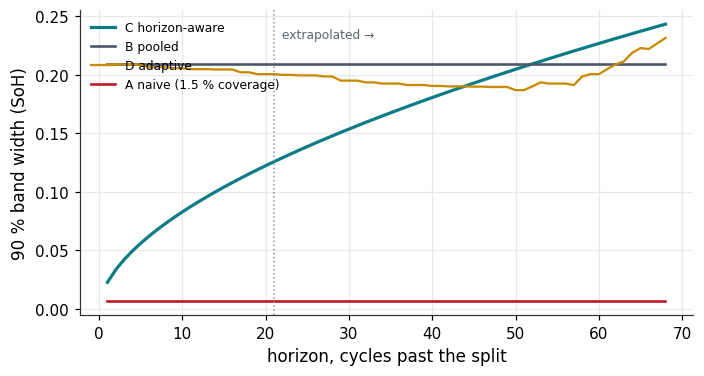

saved fig/f_otwin04_bands.png


'fig/f_otwin04_bands.png'

In [10]:
H = np.arange(1, n_te+1)
fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.plot(H, 2*C.half_width, "-", color=TEAL, lw=2.1, label="C horizon-aware")
ax.plot(H, np.full(n_te, 2*B.half_width[0]), "-", color=SLATE, lw=1.7, label="B pooled")
ax.plot(H, [h["width"] for h in aci.history], "-", color="#C98A00", lw=1.5, label="D adaptive")
ax.plot(H, np.full(n_te, 2*A.half_width[0]), "-", color=RED, lw=1.7, label="A naive (1.5 % coverage)")
first_ex = int(np.argmax(C.extrapolated)) if C.extrapolated.any() else n_te
ax.axvline(first_ex + 1, color="#8A94A6", ls=":", lw=1.0); ax.text(first_ex + 2, 2*C.half_width.max()*0.95, "extrapolated →", fontsize=8, color="#5A6472")
ax.set_xlabel("horizon, cycles past the split"); ax.set_ylabel("90 % band width (SoH)")
ax.legend(frameon=False, fontsize=8, loc="upper left"); despine(ax); save(fig, "f_otwin04_bands")


## 6 · Change one thing

- **Ask for more than the data can give.** In section 3, change `level=0.90` to `0.99` in
  `horizon_conformal`. A 99 % quantile needs 99 residuals per horizon; watch how many horizons
  survive and how much of the band is extrapolated.
- **Fewer origins.** Use `origins=range(70, 100, 10)` — three refits instead of twelve — and
  watch band B's coverage move. The calibration set is the binding constraint, not the model.
- **A faster ACI.** Set `gamma=0.1`. The adaptive band reacts harder to each miss; see whether
  coverage improves or the width just oscillates.

In [11]:
# Try it: a 99 % horizon-aware band from the same 390 residuals.
try:
    C99 = horizon_conformal(res, hor, level=0.99, max_horizon=n_te)
    lo, hi = C99.apply(pred)
    print("99 %% band: calibrated horizons %d, extrapolated %d of %d, coverage %.3f, mean width %.3f"
          % (int((~C99.extrapolated).sum()), int(C99.extrapolated.sum()), n_te, picp(obs, lo, hi), mpiw(lo, hi)))
except ValueError as e:
    print("refused:", e)
    B99 = split_conformal(res, level=0.99); lo, hi = B99.apply(pred)
    print("\npooled 99 %% band instead: coverage %.3f, mean width %.3f  (vs 90 %%: %.3f, %.3f)"
          % (picp(obs, lo, hi), mpiw(lo, hi), cov["B pooled rolling-origin"], mpiw(*B.apply(pred))))

refused: a horizon-aware band needs at least two horizons with 99+ residuals each (the minimum a 99% conformal quantile exists at); got 0. Use split_conformal, which pools every horizon together.

pooled 99 % band instead: coverage 1.000, mean width 0.292  (vs 90 %: 0.868, 0.209)


## What you learned

- In-sample residuals describe the fit, not the forecast. On this cell they are 9× too small.
- Calibrate on genuine h-step-ahead errors from earlier origins; `rolling_origin_residuals`
  generates them without touching the test window.
- Let the band grow with horizon, and let the library refuse the horizons it cannot measure.
- `interval_score` ranks bands without a debate. Use it.

**Next:** [notebook 05](otwin_05_estimating_the_state.ipynb) — correcting the state from
measurements, and why an estimator should know about energy.

---
*For CI, not for you.*

In [12]:
REFERENCE = [
    ("naive in-sample coverage",        float(cov["A naive in-sample"]),       0.014705882352941176, 2e-2),
    ("pooled rolling-origin coverage",  float(cov["B pooled rolling-origin"]), 0.8676470588235294,   2e-2),
    ("horizon-aware coverage (library)",float(cov["C horizon-aware"]),         0.9558823529411765,   2e-2),
    ("adaptive (ACI) coverage",         float(cov["D adaptive (ACI)"]),        0.8235294117647058,   2e-2),
]
print(f"{'quantity':<40} {'this run':>12}  {'reference':>12}  {'match':>6}"); print("-"*76)
_bad = []
for name, got, ref, tol in REFERENCE:
    ok = abs(got-ref) <= max(1e-12, tol*max(abs(ref), 1e-12))
    print(f"{name:<40} {got:>12.6g}  {ref:>12.6g}  {'yes' if ok else 'NO':>6}")
    if not ok: _bad.append(name)
assert not _bad, f"headline numbers drifted: {_bad}"
print("\nregression test passed")


quantity                                     this run     reference   match
----------------------------------------------------------------------------
naive in-sample coverage                    0.0147059     0.0147059     yes
pooled rolling-origin coverage               0.867647      0.867647     yes
horizon-aware coverage (library)             0.955882      0.955882     yes
adaptive (ACI) coverage                      0.823529      0.823529     yes

regression test passed
